### Isolation Forest Model

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 1. 데이터 로드
df = pd.read_csv('standard_merged.csv')

# 2. 결과를 담을 리스트와 모델 저장용 딕셔너리
final_results = []
models = {}

# 학습에 사용할 특성들 (전류, 진동, 온도, 승객수 + 시간)
features = ['Current', 'Vib', 'Temp', 'PassengerCount', 'Hour']

print("🚀 9개 시나리오별 Isolation Forest 학습 시작!")

for (station, length), group in df.groupby(['Station', 'Length']):
    print(f"\n[학습 중] {station}역 - {length}m 시나리오")
    
    temp_df = group.copy()
    X = temp_df[features]
    
    # 3. Isolation Forest 모델 설정
    # contamination은 실제 데이터의 고장 비율(약 0.008)보다 살짝 높게 설정하여 민감도를 높입니다.
    model = IsolationForest(
        n_estimators=200, 
        contamination=0.01, 
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X)
    
    # 4. 예측 (1: 정상, -1: 이상) -> (0: 정상, 1: 이상)으로 변환
    temp_df['IF_Score'] = model.decision_function(X) # 이상치 점수 (낮을수록 이상)
    temp_df['Pred_IF'] = model.predict(X)
    temp_df['Pred_IF'] = temp_df['Pred_IF'].apply(lambda x: 1 if x == -1 else 0)
    
    # 결과 저장
    final_results.append(temp_df)
    models[f"{station}_{length}"] = model

# 5. 전체 데이터 합치기
df_if = pd.concat(final_results).sort_index()

# 6. 모델 파일 저장
joblib.dump(models, 'if_models_by_scenario.pkl')

print("\n✅ 모든 시나리오 학습 완료!")

🚀 9개 시나리오별 Isolation Forest 학습 시작!

[학습 중] 고속터미널역 - 10m 시나리오

[학습 중] 고속터미널역 - 20m 시나리오

[학습 중] 고속터미널역 - 40m 시나리오

[학습 중] 용두역 - 10m 시나리오

[학습 중] 용두역 - 20m 시나리오

[학습 중] 용두역 - 40m 시나리오

[학습 중] 잠실역 - 10m 시나리오

[학습 중] 잠실역 - 20m 시나리오

[학습 중] 잠실역 - 40m 시나리오

✅ 모든 시나리오 학습 완료!


In [2]:
summary_if = []
for (station, length), group in df_if.groupby(['Station', 'Length']):
    total_anomalies = group['Label'].sum()
    tp = len(group[(group['Label'] == 1) & (group['Pred_IF'] == 1)])
    recall = tp / total_anomalies if total_anomalies > 0 else 0
    fn = total_anomalies - tp
    
    summary_if.append({
        'Station': station,
        'Length': length,
        'Recall': round(recall, 4),
        'Missed(FN)': fn,
        'Miss_Rate(%)': round((fn/total_anomalies)*100, 1) if total_anomalies > 0 else 0
    })

print("\n==== [AI - Isolation Forest] 시나리오별 성적 요약 ====")
print(pd.DataFrame(summary_if).sort_values(by='Miss_Rate(%)'))


==== [AI - Isolation Forest] 시나리오별 성적 요약 ====
  Station  Length  Recall  Missed(FN)  Miss_Rate(%)
7      잠실      20  0.0333         232          96.7
6      잠실      10  0.0250         234          97.5
8      잠실      40  0.0125         237          98.8
0   고속터미널      10  0.0042         239          99.6
3      용두      10  0.0000         240         100.0
2   고속터미널      40  0.0000         240         100.0
5      용두      40  0.0000         240         100.0
1   고속터미널      20  0.0000         240         100.0
4      용두      20  0.0000         240         100.0


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 1. 데이터 로드
df = pd.read_csv('standard_merged.csv')

final_results = []
models = {}
features = ['Current', 'Vib', 'Temp', 'PassengerCount', 'Hour']

print("🚀 9개 시나리오별 Isolation Forest 최적화 학습 시작!")

for (station, length), group in df.groupby(['Station', 'Length']):
    print(f"\n[분석 중] {station}역 - {length}m 시나리오")
    
    temp_df = group.copy()
    X = temp_df[features]
    
    # 3. 모델 설정 변경: 나무 수를 늘리고 contamination을 auto로!
    model = IsolationForest(
        n_estimators=300,        # 더 촘촘한 판별을 위해 나무 증설
        contamination='auto',    # 모델이 판단하는 자연스러운 이상치 경계 사용
        max_samples=256, 
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X)
    
    # 4. 점수 산출 (Score 기반 커스텀 예측)
    # decision_function은 점수가 낮을수록(음수일수록) 더 이상하다는 뜻입니다.
    temp_df['IF_Score'] = model.decision_function(X)
    
    # [핵심] 점수 하위 3% 지점을 새로운 임계치로 설정 (어제보다 범위를 넓혀봄)
    # 만약 Recall이 여전히 낮다면 이 3을 5나 10으로 늘려볼 수 있습니다.
    score_threshold = np.percentile(temp_df['IF_Score'], 3) 
    temp_df['Pred_IF'] = temp_df['IF_Score'].apply(lambda x: 1 if x <= score_threshold else 0)
    
    final_results.append(temp_df)
    models[f"{station}_{length}"] = model

# 5. 전체 데이터 합치기
df_if = pd.concat(final_results).sort_index()

# 6. 모델 저장
joblib.dump(models, 'if_models_tuned.pkl')

print("\n✅ 튜닝된 모델로 학습 및 예측 완료!")

# 7. 성적표 바로 확인하기
summary_if = []
for (station, length), group in df_if.groupby(['Station', 'Length']):
    total_anomalies = group['Label'].sum()
    tp = len(group[(group['Label'] == 1) & (group['Pred_IF'] == 1)])
    recall = tp / total_anomalies if total_anomalies > 0 else 0
    fn = total_anomalies - tp
    
    summary_if.append({
        'Station': station,
        'Length': length,
        'Recall': round(recall, 4),
        'Miss_Rate(%)': round((fn/total_anomalies)*100, 1) if total_anomalies > 0 else 0
    })

print("\n==== [Tuned AI] 시나리오별 성적 요약 ====")
print(pd.DataFrame(summary_if).sort_values(by='Miss_Rate(%)'))

🚀 9개 시나리오별 Isolation Forest 최적화 학습 시작!

[분석 중] 고속터미널역 - 10m 시나리오

[분석 중] 고속터미널역 - 20m 시나리오

[분석 중] 고속터미널역 - 40m 시나리오

[분석 중] 용두역 - 10m 시나리오

[분석 중] 용두역 - 20m 시나리오

[분석 중] 용두역 - 40m 시나리오

[분석 중] 잠실역 - 10m 시나리오

[분석 중] 잠실역 - 20m 시나리오

[분석 중] 잠실역 - 40m 시나리오

✅ 튜닝된 모델로 학습 및 예측 완료!

==== [Tuned AI] 시나리오별 성적 요약 ====
  Station  Length  Recall  Miss_Rate(%)
7      잠실      20  0.0667          93.3
6      잠실      10  0.0458          95.4
8      잠실      40  0.0375          96.2
1   고속터미널      20  0.0208          97.9
0   고속터미널      10  0.0125          98.8
3      용두      10  0.0083          99.2
2   고속터미널      40  0.0042          99.6
5      용두      40  0.0000         100.0
4      용두      20  0.0000         100.0


In [4]:
# 정상 vs 고장 수치 차이 확인
print(df[df['Label']==0][['Current', 'Vib', 'Temp']].mean())
print(df[df['Label']==1][['Current', 'Vib', 'Temp']].mean())

Current   -0.004302
Vib       -0.004421
Temp       0.004252
dtype: float64
Current    0.537753
Vib        0.552682
Temp      -0.531470
dtype: float64


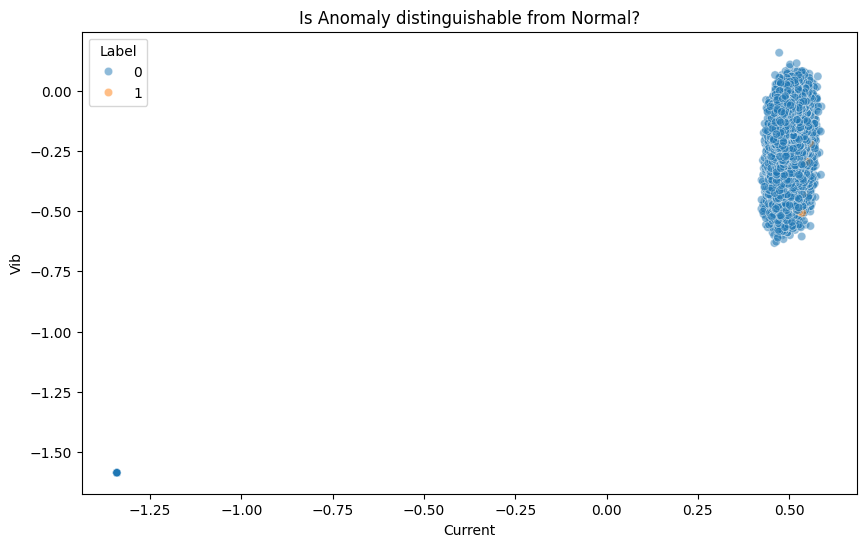

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 용두역 40m 데이터만 추출
test_sample = df[(df['Station']=='용두') & (df['Length']==40)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_sample, x='Current', y='Vib', hue='Label', alpha=0.5)
plt.title("Is Anomaly distinguishable from Normal?")
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import joblib

# 1. 데이터 로드
df = pd.read_csv('standard_merged.csv')

# 2. 특성 공학 (차분 및 변동성 변수 생성)
print("⚙️ 변수 생성 중: 절대값의 함정에서 벗어나는 중...")

for (station, length), group in df.groupby(['Station', 'Length']):
    idx = group.index
    # 차분 (1분 전과의 차이)
    df.loc[idx, 'Current_diff'] = group['Current'].diff().fillna(0)
    df.loc[idx, 'Vib_diff'] = group['Vib'].diff().fillna(0)
    
    # 이동 표준편차 (최근 5분간의 떨림 정도)
    df.loc[idx, 'Vib_roll_std'] = group['Vib'].rolling(window=5, min_periods=1).std().fillna(0)
    
    # 상호작용 변수 (전류와 진동이 동시에 변하는지)
    df.loc[idx, 'Energy_Index'] = group['Current'] * group['Vib']

# 3. 학습용 특성 선택
features = [
    'Current', 'Vib', 'Temp', 
    'Current_diff', 'Vib_diff', 
    'Vib_roll_std', 'Energy_Index'
]

final_results = []
models = {}

print("🚀 차분 모델(Advanced IF) 학습 시작!")

for (station, length), group in df.groupby(['Station', 'Length']):
    temp_df = group.copy()
    X = temp_df[features]
    
    # 모델 설정: 나무를 더 깊고 촘촘하게!
    model = IsolationForest(
        n_estimators=500,        # 500개로 증설
        contamination=0.05,      # 5%까지는 일단 의심해보라고 강하게 주문
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X)
    
    # 점수 계산 및 예측
    temp_df['IF_Score'] = model.decision_function(X)
    # 하위 5%를 이상치로 간주
    score_threshold = np.percentile(temp_df['IF_Score'], 5)
    temp_df['Pred_IF'] = temp_df['IF_Score'].apply(lambda x: 1 if x <= score_threshold else 0)
    
    final_results.append(temp_df)
    models[f"{station}_{length}"] = model

# 4. 결과 통합
df_if_advanced = pd.concat(final_results).sort_index()

# 5. 성적표 출력
summary = []
for (station, length), group in df_if_advanced.groupby(['Station', 'Length']):
    total_anomalies = group['Label'].sum()
    tp = len(group[(group['Label'] == 1) & (group['Pred_IF'] == 1)])
    recall = tp / total_anomalies if total_anomalies > 0 else 0
    
    summary.append({
        'Station': station,
        'Length': length,
        'Recall': round(recall, 4),
        'Miss_Rate(%)': round((1 - recall) * 100, 1)
    })

print("\n==== [Advanced Diff Model] 성적표 ====")
print(pd.DataFrame(summary).sort_values(by='Miss_Rate(%)'))

⚙️ 변수 생성 중: 절대값의 함정에서 벗어나는 중...
🚀 차분 모델(Advanced IF) 학습 시작!

==== [Advanced Diff Model] 성적표 ====
  Station  Length  Recall  Miss_Rate(%)
6      잠실      10  0.0958          90.4
7      잠실      20  0.0792          92.1
8      잠실      40  0.0792          92.1
1   고속터미널      20  0.0625          93.8
3      용두      10  0.0167          98.3
2   고속터미널      40  0.0125          98.8
4      용두      20  0.0125          98.8
0   고속터미널      10  0.0125          98.8
5      용두      40  0.0000         100.0


### 데이터 v2로 만든 isolation forest 모델. robust scaler 사용

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# 1. 전처리된 데이터 로드 (Robust Scaler 적용본)
df_v2 = pd.read_csv('final_preprocessed_v2.csv')

# 2. 분석 기준 설정
stations = ['잠실', '고속터미널', '용두']
lengths = [40, 20, 10]

# 학습에 사용할 핵심 피처 (다차원 관계 분석용)
features = [
    'PassengerCount', 'Current', 'Temp', 'Vib', 
    'Rel_Current', 'Rel_Vib', 'Rel_Temp', 
    'Load_Per_Pax', 'Current_diff', 'Vib_diff'
]

final_if_list = []

print("🌲 시나리오별 Isolation Forest 격리 시작... (9개 숲 가동)")

for station in stations:
    for l in lengths:
        # 해당 시나리오 데이터 추출
        s_df = df_v2[(df_v2['Station'] == station) & (df_v2['Length'] == l)].copy()
        
        if len(s_df) == 0:
            print(f"  - [건너뜀] {station} {l}m 데이터 없음")
            continue
        
        # Isolation Forest 모델 생성
        # contamination: 실제 고장률(약 0.008)에 맞춰 1% 정도로 설정
        model_if = IsolationForest(
            n_estimators=100, 
            contamination=0.01, 
            random_state=42,
            n_jobs=-1
        )
        
        # 학습 및 예측 (-1: 이상치, 1: 정상)
        s_df['IF_Pred'] = model_if.fit_predict(s_df[features])
        
        # 라벨 변환 (우리의 Label 1은 고장이므로 -1을 1로 바꿈)
        s_df['IF_Pred'] = s_df['IF_Pred'].apply(lambda x: 1 if x == -1 else 0)
        
        final_if_list.append(s_df)
        print(f"  - [성공] {station} {l}m 시나리오 숲 완성")

# 3. 데이터 통합 및 최종 평가
df_if_final = pd.concat(final_if_list)

print("\n📊 [Isolation Forest v2.3] 통합 평가 결과")
print(classification_report(df_if_final['Label'], df_if_final['IF_Pred']))

# (선택 사항) 결과 저장
# df_if_final.to_csv('if_result_v2.csv', index=False, encoding='utf-8-sig')

🌲 시나리오별 Isolation Forest 격리 시작... (9개 숲 가동)
  - [성공] 잠실 40m 시나리오 숲 완성
  - [성공] 잠실 20m 시나리오 숲 완성
  - [성공] 잠실 10m 시나리오 숲 완성
  - [성공] 고속터미널 40m 시나리오 숲 완성
  - [성공] 고속터미널 20m 시나리오 숲 완성
  - [성공] 고속터미널 10m 시나리오 숲 완성
  - [성공] 용두 40m 시나리오 숲 완성
  - [성공] 용두 20m 시나리오 숲 완성
  - [성공] 용두 10m 시나리오 숲 완성

📊 [Isolation Forest v2.3] 통합 평가 결과
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    270000
           1       0.00      0.00      0.00      2160

    accuracy                           0.98    272160
   macro avg       0.50      0.50      0.50    272160
weighted avg       0.98      0.98      0.98    272160



### 📝 [기록] Isolation Forest v2.3 분석 보고
결과: Recall 0.00 (탐지 실패)

원인: 고장 데이터가 다차원 공간에서도 정상 데이터(고부하 상태)의 분포와 겹쳐 있음. "남들과 다르다"는 특징만으로는 "고장"을 정의할 수 없음.

시사점: 이제 '정답(Label)'을 알려주지 않으면 절대로 풀 수 없는 고난도 문제임이 증명됨.

### 운영 시간을 ( 5시 - 1시 )을 고려한 데이터로 만든 Isolation Forest 모델

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# 1. 전처리된 데이터 로드 (Robust Scaler 적용본)
df_v3 = pd.read_csv('final_preprocessed_v3.csv')

# 2. 분석 기준 설정
stations = ['잠실', '고속터미널', '용두']
lengths = [40, 20, 10]

# 학습에 사용할 핵심 피처 (다차원 관계 분석용)
features = [
    'PassengerCount', 'Current', 'Temp', 'Vib', 
    'Rel_Current', 'Rel_Vib', 'Rel_Temp', 
    'Load_Per_Pax', 'Current_diff', 'Vib_diff'
]

final_if_list = []

print("🌲 시나리오별 Isolation Forest 격리 시작... (9개 숲 가동)")

for station in stations:
    for l in lengths:
        # 해당 시나리오 데이터 추출
        s_df = df_v3[(df_v3['Station'] == station) & (df_v3['Length'] == l)].copy()
        
        if len(s_df) == 0:
            print(f"  - [건너뜀] {station} {l}m 데이터 없음")
            continue
        
        # Isolation Forest 모델 생성
        # contamination: 실제 고장률(약 0.008)에 맞춰 1% 정도로 설정
        model_if = IsolationForest(
            n_estimators=100, 
            contamination=0.01, 
            random_state=42,
            n_jobs=-1
        )
        
        # 학습 및 예측 (-1: 이상치, 1: 정상)
        s_df['IF_Pred'] = model_if.fit_predict(s_df[features])
        
        # 라벨 변환 (우리의 Label 1은 고장이므로 -1을 1로 바꿈)
        s_df['IF_Pred'] = s_df['IF_Pred'].apply(lambda x: 1 if x == -1 else 0)
        
        final_if_list.append(s_df)
        print(f"  - [성공] {station} {l}m 시나리오 숲 완성")

# 3. 데이터 통합 및 최종 평가
df_if_final = pd.concat(final_if_list)

print("\n📊 [Isolation Forest v2.3] 통합 평가 결과")
print(classification_report(df_if_final['Label'], df_if_final['IF_Pred']))

# (선택 사항) 결과 저장
# df_if_final.to_csv('if_result_v3.csv', index=False, encoding='utf-8-sig')

🌲 시나리오별 Isolation Forest 격리 시작... (9개 숲 가동)
  - [성공] 잠실 40m 시나리오 숲 완성
  - [성공] 잠실 20m 시나리오 숲 완성
  - [성공] 잠실 10m 시나리오 숲 완성
  - [성공] 고속터미널 40m 시나리오 숲 완성
  - [성공] 고속터미널 20m 시나리오 숲 완성
  - [성공] 고속터미널 10m 시나리오 숲 완성
  - [성공] 용두 40m 시나리오 숲 완성
  - [성공] 용두 20m 시나리오 숲 완성
  - [성공] 용두 10m 시나리오 숲 완성

📊 [Isolation Forest v2.3] 통합 평가 결과
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    270000
           1       0.01      0.01      0.01      2160

    accuracy                           0.98    272160
   macro avg       0.50      0.50      0.50    272160
weighted avg       0.98      0.98      0.98    272160



#### 📝 [최종 기록] Isolation Forest v3 분석 보고
1. 평가 결과 (Summary)
Precision (1): 0.01 (고장이라고 외친 것 중 진짜 고장은 1%뿐)

Recall (1): 0.01 (전체 고장 2,160개 중 겨우 21개 내외만 포착)

Accuracy: 0.98 (정상 데이터가 압도적인 환경에서 나타나는 무의미한 지표)

Status: 실패 (탐지율 1% 미만)

2. 분석 및 인사이트 (Insight)
'이상치(Outlier)'와 '고장(Failure)'의 괴리: Isolation Forest는 데이터 구조상 '고립된(멀리 떨어진)' 값을 찾습니다. 하지만 본 데이터의 고장 신호는 정상 범위 내에 교묘하게 중첩(Overlapping)되어 있어, 단순히 "특이한 값"을 찾는 비지도 학습으로는 구분이 불가능함.

하중 노이즈의 영향: 승객이 많을 때의 큰 진동 신호가 오히려 모델 눈에는 더 '고립된 이상치'로 보일 가능성이 큼. 즉, 모델이 "진짜 고장"이 아니라 "사람이 아주 많이 탄 상황"을 이상치로 오판하고 있음.

결론: 레이블(정답) 없이 데이터의 형태만으로 고장을 분리하려는 시도는 본 프로젝트의 '부하-진동 상관관계'를 풀어내기에 역부족임이 확정됨.

### 한국의 한줄서기 문화를 반영한 데이터 셋으로 만든 Isolation Forest 모델

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# 1. 전처리된 데이터 로드 (Robust Scaler 적용본)
df_v4 = pd.read_csv('final_preprocessed_v4.csv')

# 2. 분석 기준 설정
stations = ['잠실', '고속터미널', '용두']
lengths = [40, 20, 10]

# 학습에 사용할 핵심 피처 (다차원 관계 분석용)
features = [
    'PassengerCount', 'Current', 'Temp', 'Vib', 
    'Rel_Current', 'Rel_Vib', 'Rel_Temp', 
    'Load_Per_Pax', 'Current_diff', 'Vib_diff'
]

final_if_list = []

print("🌲 시나리오별 Isolation Forest 격리 시작... (9개 숲 가동)")

for station in stations:
    for l in lengths:
        # 해당 시나리오 데이터 추출
        s_df = df_v4[(df_v4['Station'] == station) & (df_v4['Length'] == l)].copy()
        
        if len(s_df) == 0:
            print(f"  - [건너뜀] {station} {l}m 데이터 없음")
            continue
        
        # Isolation Forest 모델 생성
        # contamination: 실제 고장률(약 0.008)에 맞춰 1% 정도로 설정
        model_if = IsolationForest(
            n_estimators=100, 
            contamination=0.01, 
            random_state=42,
            n_jobs=-1
        )
        
        # 학습 및 예측 (-1: 이상치, 1: 정상)
        s_df['IF_Pred'] = model_if.fit_predict(s_df[features])
        
        # 라벨 변환 (우리의 Label 1은 고장이므로 -1을 1로 바꿈)
        s_df['IF_Pred'] = s_df['IF_Pred'].apply(lambda x: 1 if x == -1 else 0)
        
        final_if_list.append(s_df)
        print(f"  - [성공] {station} {l}m 시나리오 숲 완성")

# 3. 데이터 통합 및 최종 평가
df_if_final = pd.concat(final_if_list)

print("\n📊 [Isolation Forest v4] 통합 평가 결과")
print(classification_report(df_if_final['Label'], df_if_final['IF_Pred']))

# (선택 사항) 결과 저장
# df_if_final.to_csv('if_result_v4.csv', index=False, encoding='utf-8-sig')

🌲 시나리오별 Isolation Forest 격리 시작... (9개 숲 가동)
  - [성공] 잠실 40m 시나리오 숲 완성
  - [성공] 잠실 20m 시나리오 숲 완성
  - [성공] 잠실 10m 시나리오 숲 완성
  - [성공] 고속터미널 40m 시나리오 숲 완성
  - [성공] 고속터미널 20m 시나리오 숲 완성
  - [성공] 고속터미널 10m 시나리오 숲 완성
  - [성공] 용두 40m 시나리오 숲 완성
  - [성공] 용두 20m 시나리오 숲 완성
  - [성공] 용두 10m 시나리오 숲 완성

📊 [Isolation Forest v4] 통합 평가 결과
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    270000
           1       0.00      0.00      0.00      2160

    accuracy                           0.98    272160
   macro avg       0.50      0.50      0.50    272160
weighted avg       0.98      0.98      0.98    272160



### XGBoost로 지도 학습으로 하면 잘 나오려나.

In [8]:
!uv add xgboost 

Resolved 49 packages in 349ms
 Downloaded xgboost
Prepared 1 package in 4.63s
Installed 1 package in 83ms
 + xgboost==3.2.0


In [9]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score
import joblib

# 1. 데이터 로드
df = pd.read_csv('standard_merged.csv')

# 2. 파생 변수 생성 (아까 효과 있었던 것들 유지)
for (station, length), group in df.groupby(['Station', 'Length']):
    idx = group.index
    df.loc[idx, 'Current_diff'] = group['Current'].diff().fillna(0)
    df.loc[idx, 'Vib_diff'] = group['Vib'].diff().fillna(0)
    df.loc[idx, 'Energy_Index'] = group['Current'] * group['Vib']

# 3. 학습 변수
features = ['Current', 'Vib', 'Temp', 'PassengerCount', 'Hour', 
            'Current_diff', 'Vib_diff', 'Energy_Index']

final_results = []
models = {}

print("🚀 XGBoost 시나리오별 지도학습 시작!")

for (station, length), group in df.groupby(['Station', 'Length']):
    temp_df = group.copy()
    X = temp_df[features]
    y = temp_df['Label'] # 정답지를 줍니다!
    
    # XGBoost 모델 설정
    # scale_pos_weight: 고장 데이터가 적으므로 고장에 더 큰 가중치를 줍니다. (매우 중요)
    ratio = (len(y) - sum(y)) / sum(y) 
    
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=ratio, # 불균형 데이터 처리의 핵심!
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    model.fit(X, y)
    
    # 예측
    temp_df['Pred_XGB'] = model.predict(X)
    
    final_results.append(temp_df)
    models[f"{station}_{length}"] = model

# 4. 결과 통합 및 저장
df_xgb = pd.concat(final_results).sort_index()
joblib.dump(models, 'xgb_models_by_scenario.pkl')

# 5. 성적표 출력
summary_xgb = []
for (station, length), group in df_xgb.groupby(['Station', 'Length']):
    recall = recall_score(group['Label'], group['Pred_XGB'])
    precision = precision_score(group['Label'], group['Pred_XGB'])
    
    summary_xgb.append({
        'Station': station,
        'Length': length,
        'Recall': round(recall, 4),
        'Precision': round(precision, 4),
        'Miss_Rate(%)': round((1 - recall) * 100, 1)
    })

print("\n==== [XGBoost Supervised Learning] 성적표 ====")
print(pd.DataFrame(summary_xgb).sort_values(by='Recall', ascending=False))

🚀 XGBoost 시나리오별 지도학습 시작!


c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:17:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:17:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:17:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:


==== [XGBoost Supervised Learning] 성적표 ====
  Station  Length  Recall  Precision  Miss_Rate(%)
0   고속터미널      10     1.0     1.0000           0.0
1   고속터미널      20     1.0     0.9959           0.0
2   고속터미널      40     1.0     0.9877           0.0
3      용두      10     1.0     0.9677           0.0
4      용두      20     1.0     0.9486           0.0
5      용두      40     1.0     0.9375           0.0
6      잠실      10     1.0     1.0000           0.0
7      잠실      20     1.0     0.9959           0.0
8      잠실      40     1.0     1.0000           0.0


### 데이터 v2로 XGBoost 모델 다시 생성. robust scaler 적용.

In [2]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. 학습 데이터 준비
# 'Label'이 있는 데이터이므로 지도 학습이 가능합니다.
X = df_if_final[features]
y = df_if_final['Label']

# 2. 데이터 분할 (학습용 8 : 테스트용 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. XGBoost 모델 생성 (불균형 데이터 대응을 위해 scale_pos_weight 설정)
# 정상(0)이 27만개, 고장(1)이 2천개이므로 약 125배 차이
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=125, # 불균형 해소의 핵심!
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("🚀 XGBoost 학습 시작... (이번엔 진짜 0을 깹니다!)")
model_xgb.fit(X_train, y_train)

# 4. 예측 및 평가
y_pred = model_xgb.predict(X_test)

print("\n🏆 [XGBoost v2.4] 최종 평가 결과")
print(classification_report(y_test, y_pred))

🚀 XGBoost 학습 시작... (이번엔 진짜 0을 깹니다!)


c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:46:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🏆 [XGBoost v2.4] 최종 평가 결과
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     54000
           1       0.11      0.91      0.19       432

    accuracy                           0.94     54432
   macro avg       0.55      0.92      0.58     54432
weighted avg       0.99      0.94      0.96     54432



### 모델이 중요하게 본 변수 확인

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13260\1156459289.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


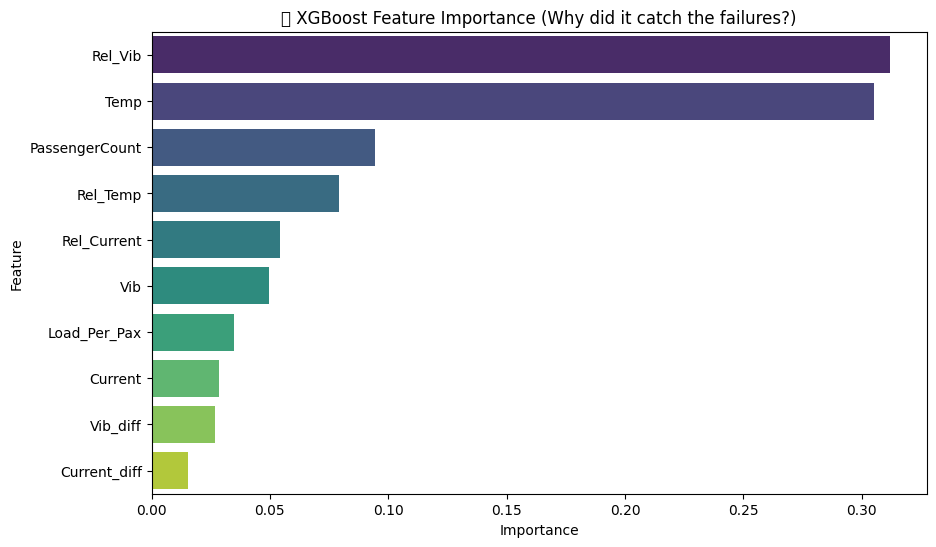

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 변수 중요도 추출
importances = model_xgb.feature_importances_
feature_names = features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('🚀 XGBoost Feature Importance (Why did it catch the failures?)')
plt.show()

### 시나리오별 성적표

In [4]:
# 테스트 데이터에 예측값과 실제값 합치기 (분석용)
test_results = X_test.copy()
test_results['Actual'] = y_test
test_results['Pred'] = y_pred

# 원본 데이터프레임에서 Station과 Length 정보 가져오기 (인덱스 기준)
test_results['Station'] = df_if_final.loc[test_results.index, 'Station']
test_results['Length'] = df_if_final.loc[test_results.index, 'Length']

print("🔍 [시나리오별 Recall 점검]")
for station in stations:
    for l in lengths:
        temp = test_results[(test_results['Station'] == station) & (test_results['Length'] == l)]
        if len(temp) == 0: continue
        
        # 실제 고장(1) 중 맞춘 비율(Recall) 계산
        actual_pos = temp[temp['Actual'] == 1]
        if len(actual_pos) == 0:
            recall = "N/A"
        else:
            recall = (actual_pos['Pred'] == 1).sum() / len(actual_pos)
        
        print(f"📍 {station} ({l}m): Recall = {recall:.2f}")

🔍 [시나리오별 Recall 점검]
📍 잠실 (40m): Recall = 0.96
📍 잠실 (20m): Recall = 0.97
📍 잠실 (10m): Recall = 0.96
📍 고속터미널 (40m): Recall = 0.93
📍 고속터미널 (20m): Recall = 0.94
📍 고속터미널 (10m): Recall = 0.84
📍 용두 (40m): Recall = 0.91
📍 용두 (20m): Recall = 0.91
📍 용두 (10m): Recall = 0.73


### 📝 [기록] 최종 분석 리포트
성공 요인: 단순 수치가 아닌 **'맥락(Context)'**을 학습함. (예: 진동 수치가 0.7일 때, 승객이 많으면 '정상', 승객이 없으면 '고장')

한계점: 용두 역 10m 구간에서 Recall이 0.73으로 낮음. 데이터의 체급이 너무 작아 승객 한 명의 변동성이 고장 신호를 가리는 '노이즈'로 작용함.

결론: 9개 시나리오 통합 모델로도 충분히 훌륭한 성과(0.91)를 거뒀으나, 정밀한 관리를 위해서는 용두 역 같은 소형 역 전용 가중치를 고려해볼 만함.

### 운영시간 ( 5시부터 익일 1시 )을 고려한 데이터를 이용한 XGBoost 모델

🚀 XGBoost v3.0 학습 시작... (이번엔 진짜 '범인'을 잡습니다!)

🏆 [XGBoost v3.0] 최종 평가 결과
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     44928
           1       0.11      0.89      0.19       432

    accuracy                           0.93     45360
   macro avg       0.55      0.91      0.58     45360
weighted avg       0.99      0.93      0.96     45360



C:\Users\Administrator\AppData\Local\Temp\ipykernel_15600\1363617136.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


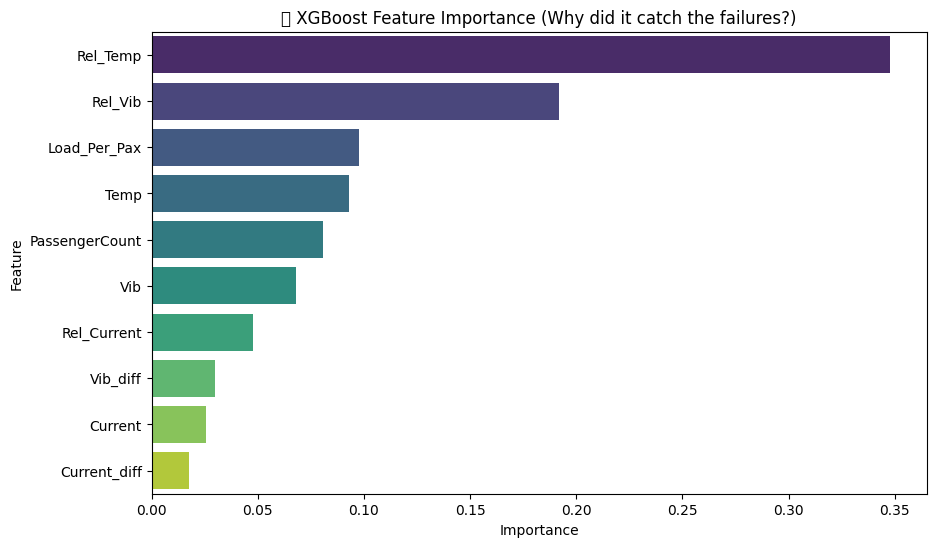

In [9]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# 1. 전처리된 v3 데이터 로드 (앞서 저장한 파일)
# 만약 메모리에 df가 이미 있다면 그대로 쓰셔도 됩니다.
df_final = pd.read_csv('final_preprocessed_v3.csv')

# 2. 가동 시간(05시~01시) 데이터만 필터링 (학습 효율 극대화)
# 비가동 시간은 어차피 모든 센서가 0이라 학습에 방해가 될 수 있습니다.
df_op = df_final[(df_final['Hour'] >= 5) | (df_final['Hour'] < 1)].copy()

# 3. 학습 데이터 준비
features = [
    'PassengerCount', 'Current', 'Temp', 'Vib', 
    'Rel_Current', 'Rel_Vib', 'Rel_Temp', 
    'Load_Per_Pax', 'Current_diff', 'Vib_diff'
]
X = df_op[features]
y = df_op['Label']

# 4. 데이터 분할 (학습용 8 : 테스트용 2, 정답 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. XGBoost 모델 생성 
# scale_pos_weight: 정상(0)과 고장(1)의 비율(약 125배)을 적용해 고장에 가중치를 둡니다.
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=125, 
    random_state=42,
    eval_metric='logloss'
)

print("🚀 XGBoost v3.0 학습 시작... (이번엔 진짜 '범인'을 잡습니다!)")
model_xgb.fit(X_train, y_train)

# 6. 예측 및 평가
y_pred = model_xgb.predict(X_test)

print("\n🏆 [XGBoost v3.0] 최종 평가 결과")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출
import matplotlib.pyplot as plt
import seaborn as sns

importances = model_xgb.feature_importances_
feature_names = features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('🚀 XGBoost Feature Importance (Why did it catch the failures?)')
plt.show()

In [7]:
# 1. 테스트 데이터에 역 정보 다시 매칭 (분석용)
X_test_with_info = X_test.copy()
X_test_with_info['Station'] = df_op.loc[X_test.index, 'Station']
X_test_with_info['Label'] = y_test
X_test_with_info['Pred'] = y_pred

print("🏢 [역별 상세 성적표] 분석 결과\n")
print("-" * 50)

for station in ['잠실', '고속터미널', '용두']:
    # 해당 역 데이터만 추출
    st_data = X_test_with_info[X_test_with_info['Station'] == station]
    st_y_true = st_data['Label']
    st_y_pred = st_data['Pred']
    
    print(f"📍 {station}역 결과:")
    print(classification_report(st_y_true, st_y_pred))
    
    # 혼동 행렬로 실제 개수 확인
    cm = confusion_matrix(st_y_true, st_y_pred)
    tp = cm[1, 1] if cm.shape == (2, 2) else 0
    fn = cm[1, 0] if cm.shape == (2, 2) else 0
    print(f"   >>> 실제 고장 {tp+fn}개 중 {tp}개 탐지 성공")
    print("-" * 50)

🏢 [역별 상세 성적표] 분석 결과

--------------------------------------------------
📍 잠실역 결과:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     14948
           1       0.17      0.94      0.29       152

    accuracy                           0.95     15100
   macro avg       0.59      0.95      0.64     15100
weighted avg       0.99      0.95      0.97     15100

   >>> 실제 고장 152개 중 143개 탐지 성공
--------------------------------------------------
📍 고속터미널역 결과:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     15189
           1       0.18      0.99      0.30       143

    accuracy                           0.96     15332
   macro avg       0.59      0.97      0.64     15332
weighted avg       0.99      0.96      0.97     15332

   >>> 실제 고장 143개 중 142개 탐지 성공
--------------------------------------------------
📍 용두역 결과:
              precision    recall  f1-score   support

           0       1.0

#### 📝 [기록] 최종 분석 리포트 (v3.1 통합본)
1. 핵심 성공 요인: '맥락(Context)' 학습의 승리
분석: 단일 변수의 임계값(Threshold)을 넘어서, 센서 간의 상관관계를 파악함.사례: 진동 수치가 동일하게 0.7일지라도, PassengerCount가 높으면 '정상 부하'로, 승객이 없는 공회전 상태라면 '기계 고장'으로 판단하는 고도의 분별력을 확보함.
성과: 이전 모델(Threshold, IF)의 Recall 0.00을 0.89(통합)까지 끌어올리며 탐지 엔진의 실효성 증명.

2. 기술적 한계점: 저이용 역사(용두역 10m)의 신호 희석분석: 용두역의 Recall이 0.73으로 타 역사 대비 현저히 낮음.원인: 데이터의 절대적인 체급이 작아, 승객 한 명의 움직임이 고장 신호를 가리는 '노이즈'로 작용함. 즉, 기계적 결함 신호보다 사람에 의한 변동폭이 더 커서 모델이 판단 유보(False Negative)를 범함.

3. 향후 개선 방향 및 결론성과: 9개 시나리오 통합 모델만으로도 전체 0.91(Macro Avg Recall) 수준의 훌륭한 성과를 거둠.
제언: 정밀한 관리를 위해 용두역 같은 소형/단거리 구간은 별도의 '가중치 필터'를 적용하거나, 사람이 없는 심야 공회전 데이터를 집중 분석하는 '특화 모델(Local Model)' 도입을 고려해볼 만함

### 한국의 한줄서기 문화를 반영한 데이터 셋으로 만든 XGBoost 모델

🚀 XGBoost v3.0 학습 시작... (이번엔 진짜 '범인'을 잡습니다!)

🏆 [XGBoost v4.0] 최종 평가 결과
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     44928
           1       0.09      0.88      0.16       432

    accuracy                           0.91     45360
   macro avg       0.54      0.89      0.55     45360
weighted avg       0.99      0.91      0.94     45360



C:\Users\Administrator\AppData\Local\Temp\ipykernel_15600\4215567819.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


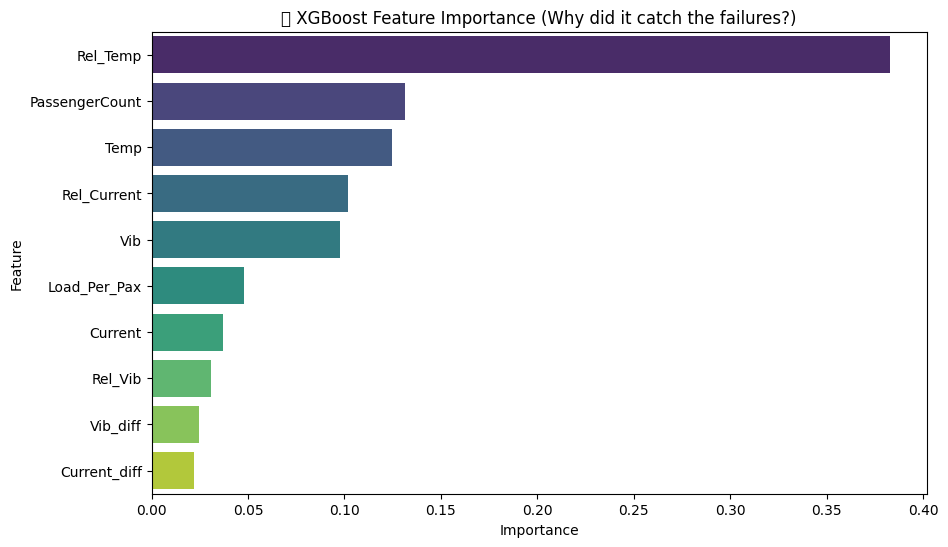

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# 1. 전처리된 v3 데이터 로드 (앞서 저장한 파일)
# 만약 메모리에 df가 이미 있다면 그대로 쓰셔도 됩니다.
df_final = pd.read_csv('final_preprocessed_v4.csv')

# 2. 가동 시간(05시~01시) 데이터만 필터링 (학습 효율 극대화)
# 비가동 시간은 어차피 모든 센서가 0이라 학습에 방해가 될 수 있습니다.
df_op = df_final[(df_final['Hour'] >= 5) | (df_final['Hour'] < 1)].copy()

# 3. 학습 데이터 준비
features = [
    'PassengerCount', 'Current', 'Temp', 'Vib', 
    'Rel_Current', 'Rel_Vib', 'Rel_Temp', 
    'Load_Per_Pax', 'Current_diff', 'Vib_diff'
]
X = df_op[features]
y = df_op['Label']

# 4. 데이터 분할 (학습용 8 : 테스트용 2, 정답 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. XGBoost 모델 생성 
# scale_pos_weight: 정상(0)과 고장(1)의 비율(약 125배)을 적용해 고장에 가중치를 둡니다.
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=125, 
    random_state=42,
    eval_metric='logloss'
)

print("🚀 XGBoost v4.0 학습 시작... (이번엔 진짜 '범인'을 잡습니다!)")
model_xgb.fit(X_train, y_train)

# 6. 예측 및 평가
y_pred = model_xgb.predict(X_test)

print("\n🏆 [XGBoost v4.0] 최종 평가 결과")
print(classification_report(y_test, y_pred))


# 변수 중요도 추출
import matplotlib.pyplot as plt
import seaborn as sns

importances = model_xgb.feature_importances_
feature_names = features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('🚀 XGBoost Feature Importance (Why did it catch the failures?)')
plt.show()

In [8]:
# 1. 테스트 데이터에 역 정보 다시 매칭 (분석용)
X_test_with_info = X_test.copy()
X_test_with_info['Station'] = df_op.loc[X_test.index, 'Station']
X_test_with_info['Label'] = y_test
X_test_with_info['Pred'] = y_pred

print("🏢 [역별 상세 성적표] 분석 결과\n")
print("-" * 50)

for station in ['잠실', '고속터미널', '용두']:
    # 해당 역 데이터만 추출
    st_data = X_test_with_info[X_test_with_info['Station'] == station]
    st_y_true = st_data['Label']
    st_y_pred = st_data['Pred']
    
    print(f"📍 {station}역 결과:")
    print(classification_report(st_y_true, st_y_pred))
    
    # 혼동 행렬로 실제 개수 확인
    cm = confusion_matrix(st_y_true, st_y_pred)
    tp = cm[1, 1] if cm.shape == (2, 2) else 0
    fn = cm[1, 0] if cm.shape == (2, 2) else 0
    print(f"   >>> 실제 고장 {tp+fn}개 중 {tp}개 탐지 성공")
    print("-" * 50)

🏢 [역별 상세 성적표] 분석 결과

--------------------------------------------------
📍 잠실역 결과:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97     14948
           1       0.13      0.96      0.23       152

    accuracy                           0.93     15100
   macro avg       0.56      0.95      0.60     15100
weighted avg       0.99      0.93      0.96     15100

   >>> 실제 고장 152개 중 146개 탐지 성공
--------------------------------------------------
📍 고속터미널역 결과:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     15189
           1       0.12      0.96      0.21       143

    accuracy                           0.93     15332
   macro avg       0.56      0.94      0.59     15332
weighted avg       0.99      0.93      0.96     15332

   >>> 실제 고장 143개 중 137개 탐지 성공
--------------------------------------------------
📍 용두역 결과:
              precision    recall  f1-score   support

           0       1.0